In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import time
import pandas as pd

In [15]:
# Load and preprocess MNIST dataset
mnist = fetch_openml('mnist_784', version=1)
X, y = mnist["data"], mnist["target"].astype(int)

In [16]:
# Normalize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

In [18]:
# Define classifiers
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
}

In [20]:
# Training, evaluation, and storing results
results = {}
misclassified_samples = {}

for name, clf in classifiers.items():
    start = time.time()
    clf.fit(X_train, y_train)
    end = time.time()
    
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    
    results[name] = {
        "accuracy": acc,
        "report": report,
        "confusion_matrix": cm,
        "training_time": end - start
    }

    mis_idx = np.where(y_test != y_pred)[0][:10]
    misclassified_samples[name] = {
        "X": X_test[mis_idx],
        "y_true": y_test.iloc[mis_idx],
        "y_pred": y_pred[mis_idx]
    }

C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [15:40:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [21]:
# Summary Table
summary_df = pd.DataFrame({
    model: {
        "Accuracy": round(metrics["accuracy"], 4),
        "Training Time (s)": round(metrics["training_time"], 2)
    }
    for model, metrics in results.items()
}).T

print("\nSummary Comparison Table:")
print(summary_df)


Summary Comparison Table:
                     Accuracy  Training Time (s)
Logistic Regression    0.9118              22.50
SVM                    0.9621             379.05
Decision Tree          0.8658              20.90
Random Forest          0.9663              45.85
XGBoost                0.9749             142.43


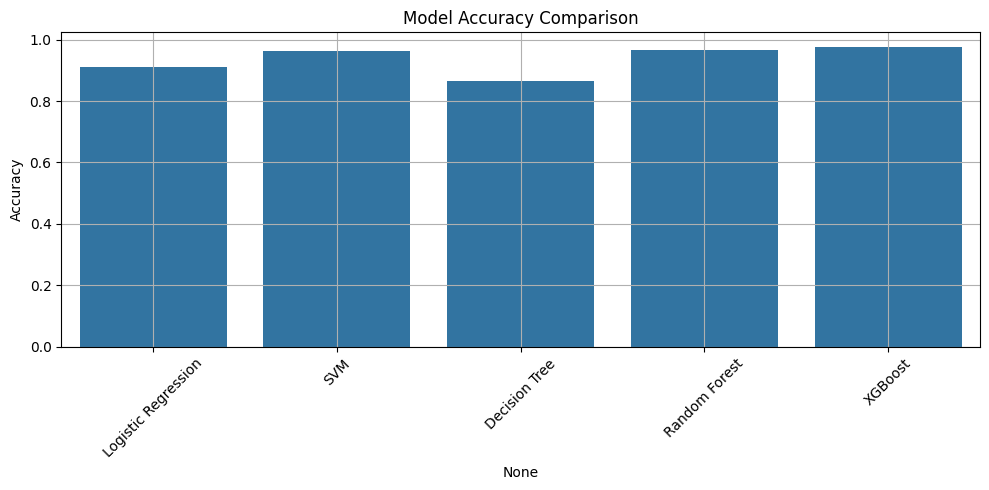

In [22]:
# Plot accuracy bar chart
plt.figure(figsize=(10, 5))
sns.barplot(x=summary_df.index, y=summary_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


Misclassified Samples for Logistic Regression:


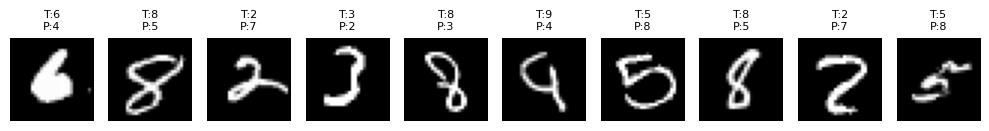


Misclassified Samples for SVM:


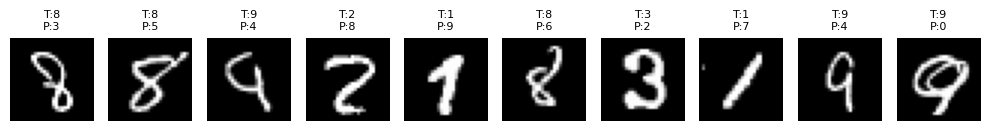


Misclassified Samples for Decision Tree:


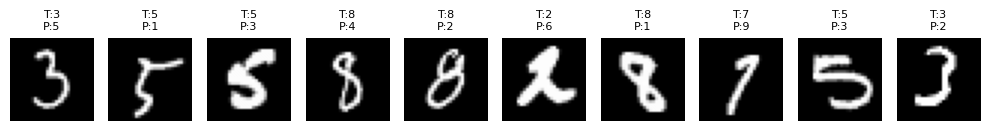


Misclassified Samples for Random Forest:


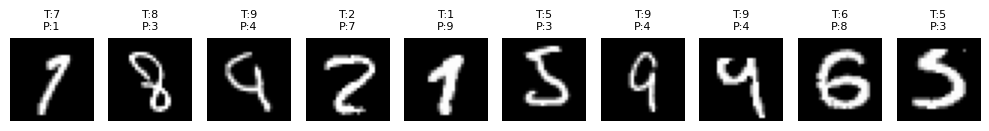


Misclassified Samples for XGBoost:


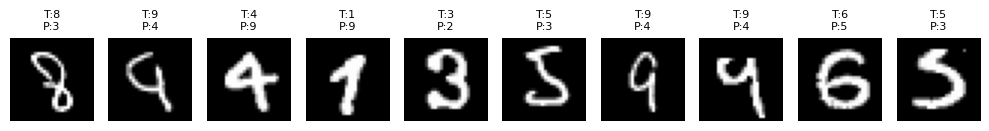

In [23]:
# Plot misclassified samples
for model_name, data in misclassified_samples.items():
    X_wrong = scaler.inverse_transform(data["X"])
    print(f"\nMisclassified Samples for {model_name}:")
    plt.figure(figsize=(10, 2))
    for i in range(len(X_wrong)):
        plt.subplot(1, 10, i+1)
        plt.imshow(X_wrong[i].reshape(28, 28), cmap='gray')
        plt.title(f"T:{data['y_true'].iloc[i]}\nP:{data['y_pred'][i]}", fontsize=8)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

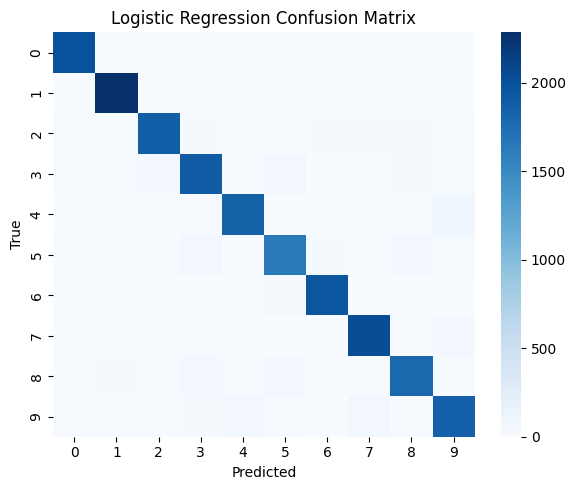

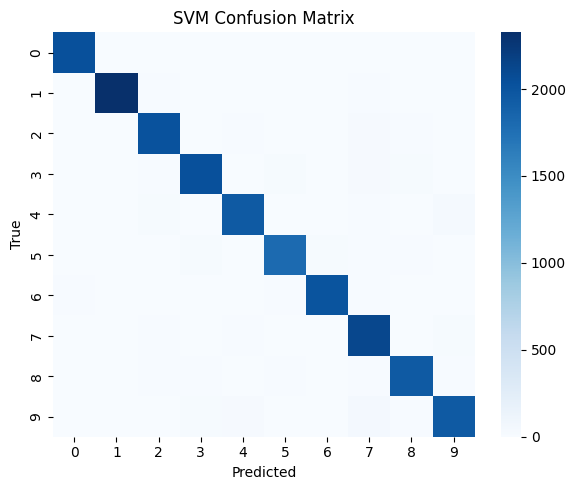

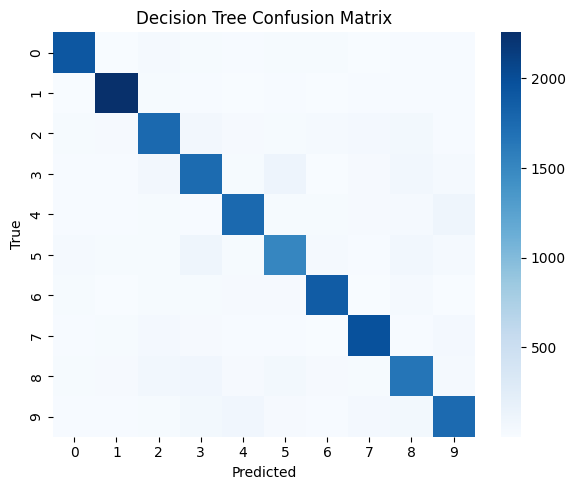

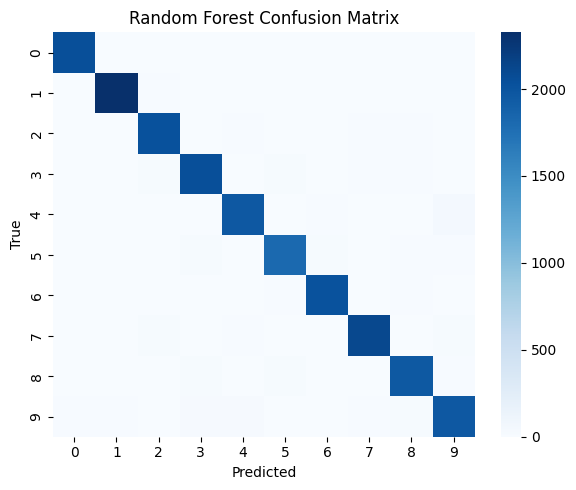

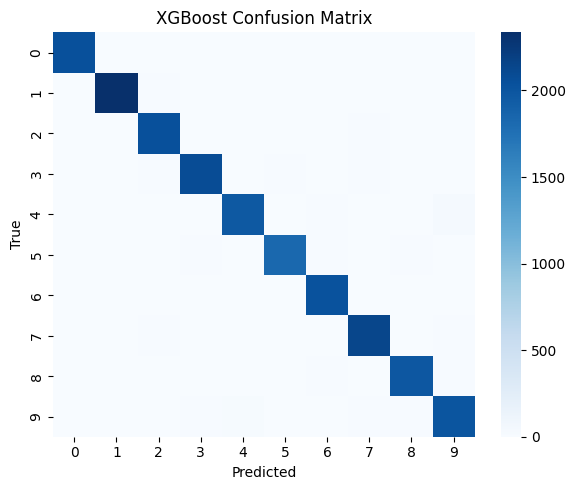

In [24]:
# Plot confusion matrices
for model_name, metrics in results.items():
    plt.figure(figsize=(6, 5))
    sns.heatmap(metrics["confusion_matrix"], annot=False, fmt="d", cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()